In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.storagelevel import StorageLevel
import matplotlib.pyplot as plt
import seaborn as sns

ĐỌC DỮ LIỆU TỪ HDFS

In [2]:
spark = (
    SparkSession.builder
    #.master("spark://100.77.205.48:7077")
    .appName("NYC Taxi Data Cleaning")
    #.config("spark.executor.memory", "1g")
    #.config("spark.driver.memory", "1g")
    .getOrCreate()
)

#print(spark.sparkContext.master)

spark.sparkContext.setLogLevel("WARN")

df = spark.read.parquet(
    #"hdfs://master:9000/output/yellow_taxi_joined"
    "hdfs://localhost:9000/output/yellow_taxi_joined"
)
# Cache trong RAM
df.cache()

# Kích hoạt cache
print(f"Total records: {df.count():,}")

spark://100.77.205.48:7077
Total records: 3,724,889


KIỂM TRA DỮ LIỆU

In [3]:
print("="*80)
print("INITIAL DATA")
print("="*80)

print("Rows:", df.count())
print("Columns:", len(df.columns))

INITIAL DATA
Rows: 3724889
Columns: 26


XỬ LÝ MISSING VALUE

Theo EDA thì số lượng hành khách 1 chiếm phần lớn nên những hàng bị missing value của coột passenger_count sẽ thay bằng 1

In [4]:
median_passenger = 1

df = df.fillna({
    "passenger_count": median_passenger
})

Theo tài liệu TLC: 99 = Unknown

In [5]:
df = df.fillna({
    "RatecodeID": 99
})

Null sẽ bằng 9 nghĩa là không phát sinh phí sân bay

In [6]:
df = df.fillna({
    "Airport_fee": 0
})

In [7]:
df = df.fillna({
    "congestion_surcharge": 0
})

In [8]:
df = df.fillna({
    "store_and_fwd_flag": "N"
})

XỬ LÝ GIÁ TRỊ KHON HỢP LỆ

Theo quy định TLC, Yellow Taxi chở tối đa 6 người => caác giá trị trên 6 bị loại bỏ

In [9]:
df = df.filter(
    (col("passenger_count") >= 1) &
    (col("passenger_count") <= 6)
)

In [10]:
df = df.filter(
    col("trip_distance") > 0
)

In [11]:
df = df.filter(
    col("fare_amount") > 0
)

In [12]:
df = df.filter(
    col("total_amount") > 0
)

In [13]:
df = df.withColumn(
    "trip_duration_minutes",
    round(
        (
            unix_timestamp("tpep_dropoff_datetime")
            -
            unix_timestamp("tpep_pickup_datetime")
        ) / 60,
        2
    )
)

In [14]:
df = df.filter(
    col("trip_duration_minutes") > 0
)

MAPPING VENDORID

In [15]:
df = df.withColumn(
    "vendor_name",
    when(col("VendorID")==1,
         "Creative Mobile Technologies")
    .when(col("VendorID")==2,
          "Curb Mobility")
    .when(col("VendorID")==6,
          "Myle Technologies")
    .when(col("VendorID")==7,
          "Helix")
    .otherwise("Unknown")
)

MAPPING RATECODEID

In [16]:
df = df.withColumn(
    "ratecode_name",
    when(col("RatecodeID")==1,"Standard")
    .when(col("RatecodeID")==2,"JFK")
    .when(col("RatecodeID")==3,"Newark")
    .when(col("RatecodeID")==4,"Nassau/Westchester")
    .when(col("RatecodeID")==5,"Negotiated")
    .when(col("RatecodeID")==6,"Group Ride")
    .otherwise("Unknown")
)

MAPPING PAYMENT TYPE

In [17]:
df = df.withColumn(
    "payment_name",
    when(col("payment_type")==0,"Flex Fare")
    .when(col("payment_type")==1,"Credit Card")
    .when(col("payment_type")==2,"Cash")
    .when(col("payment_type")==3,"No Charge")
    .when(col("payment_type")==4,"Dispute")
    .when(col("payment_type")==5,"Unknown")
    .when(col("payment_type")==6,"Voided Trip")
)

TIME FEATURES

In [18]:
df = (
    df
    .withColumn(
        "pickup_date",
        to_date("tpep_pickup_datetime")
    )
    .withColumn(
        "pickup_hour",
        hour("tpep_pickup_datetime")
    )
    .withColumn(
        "pickup_day_of_week",
        dayofweek("tpep_pickup_datetime")
    )
)

ĐỔI TÊN THỨ TRONG THỨ TRONG TUẦN

In [19]:
df = df.withColumn(
    "weekday_name",
    when(col("pickup_day_of_week")==1,"Sunday")
    .when(col("pickup_day_of_week")==2,"Monday")
    .when(col("pickup_day_of_week")==3,"Tuesday")
    .when(col("pickup_day_of_week")==4,"Wednesday")
    .when(col("pickup_day_of_week")==5,"Thursday")
    .when(col("pickup_day_of_week")==6,"Friday")
    .when(col("pickup_day_of_week")==7,"Saturday")
)

TIME PERIOD => Tạo feature mới

In [20]:
df = df.withColumn(
    "time_period",
    when(
        (col("pickup_hour")>=5) &
        (col("pickup_hour")<12),
        "Morning"
    )
    .when(
        (col("pickup_hour")>=12) &
        (col("pickup_hour")<17),
        "Afternoon"
    )
    .when(
        (col("pickup_hour")>=17) &
        (col("pickup_hour")<21),
        "Evening"
    )
    .otherwise("Night")
)

WEEKEND

In [21]:
df = df.withColumn(
    "is_weekend",
    when(
        col("pickup_day_of_week").isin(1,7),
        1
    ).otherwise(0)
)

AIRPORT TRIP

In [22]:
df = df.withColumn(
    "is_airport_trip",
    when(
        lower(col("pickup_zone"))
        .contains("airport")
        |
        lower(col("dropoff_zone"))
        .contains("airport"),
        1
    ).otherwise(0)
)

ROUTE

In [23]:
df = df.withColumn(
    "trip_route",
    concat_ws(
        " -> ",
        col("pickup_zone"),
        col("dropoff_zone")
    )
)

AVERAGE SPEED

In [24]:
df = df.withColumn(
    "avg_speed_mph",
    round(
        col("trip_distance")
        /
        (
            col("trip_duration_minutes")/60
        ),
        2
    )
)

TIP RATE

In [25]:
df = df.withColumn(
    "tip_rate",
    round(
        col("tip_amount")
        /
        col("total_amount"),
        4
    )
)

REVENUE PER MILE

In [26]:
df = df.withColumn(
    "revenue_per_mile",
    round(
        col("total_amount")
        /
        col("trip_distance"),
        2
    )
)

AIRPORT NAME

In [27]:
df = df.withColumn(
    "airport_name",
    when(
        lower(col("pickup_zone")).contains("jfk") |
        lower(col("dropoff_zone")).contains("jfk"),
        "JFK"
    )
    .when(
        lower(col("pickup_zone")).contains("laguardia") |
        lower(col("dropoff_zone")).contains("laguardia"),
        "LaGuardia"
    )
    .when(
        lower(col("pickup_zone")).contains("newark") |
        lower(col("dropoff_zone")).contains("newark"),
        "Newark"
    )
    .otherwise("Non-Airport")
)


CORRELATION

In [28]:
numeric_cols = [
    "passenger_count",
    "trip_distance",
    "trip_duration_minutes",
    "avg_speed_mph",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "tip_rate",
    "revenue_per_mile"
]

In [29]:
pdf = (
    df
    .select(numeric_cols)
    .dropna()
    .sample(False,0.05,42)
    .toPandas()
)

corr_matrix = pdf.corr()

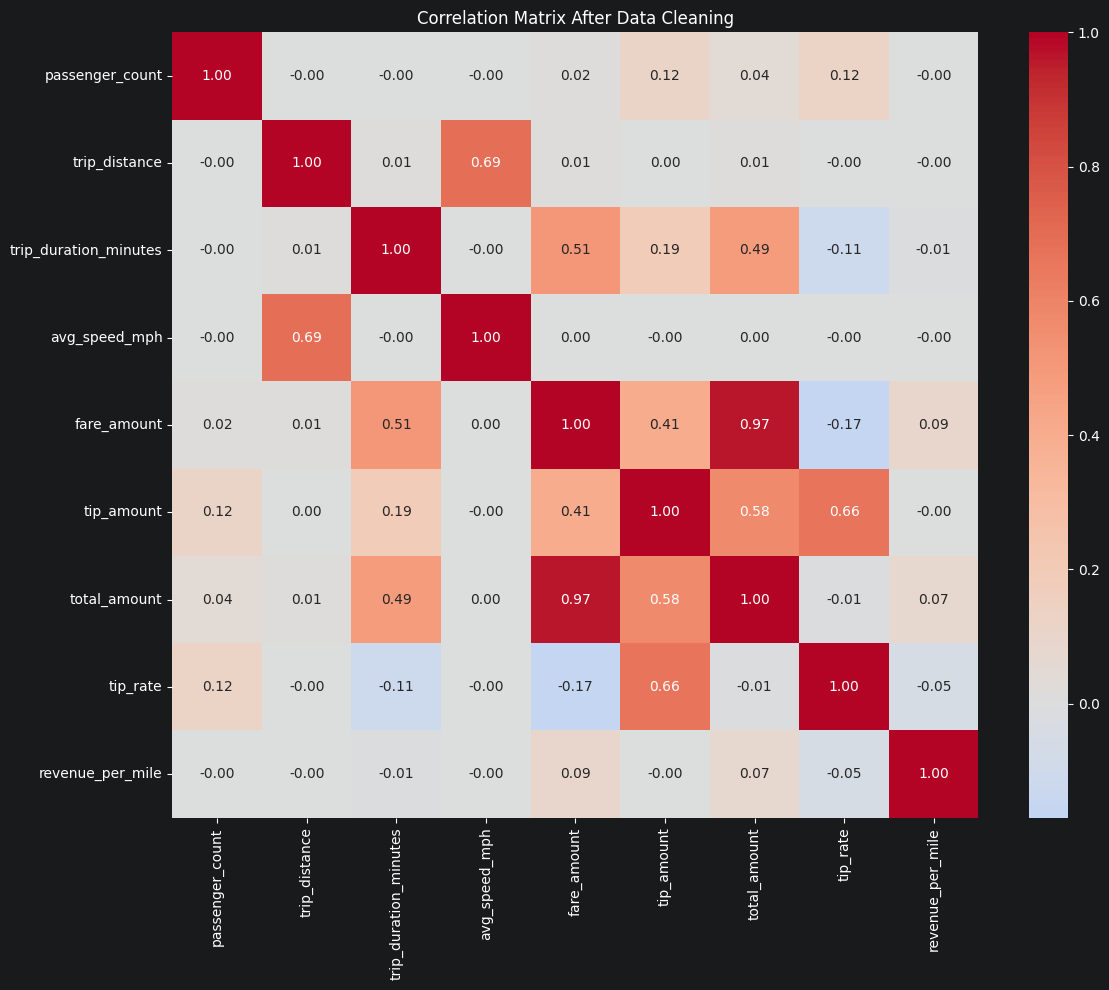

In [30]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix After Data Cleaning"
)

plt.tight_layout()
plt.show()

LƯU DỮ LIỆU ĐÃ LÀM SẠCH

In [31]:
df.write \
.mode("overwrite") \
.parquet(
    "hdfs://localhost:9000/output/yellow_taxi_cleaned"
    #"hdfs://master:9000/output/yellow_taxi_cleaned"
)

In [32]:
print("EDA COMPLETED SUCCESSFULLY")
spark.stop()

EDA COMPLETED SUCCESSFULLY
